# Customer Behavior Analysis in Online Retail

This project analyzes customer purchasing behavior using an online retail dataset.
The goal is to understand customer patterns, identify top products, analyze sales trends,
and provide business insights.

## 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

## 2. Load Dataset

In [21]:
candidate_paths = [
    Path('online_retail.csv'),
    Path('data/online_retail.csv'),
    Path('../online_retail.csv'),
    Path('../data/online_retail.csv'),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find online_retail.csv. Checked: online_retail.csv, data/online_retail.csv, ../online_retail.csv, ../data/online_retail.csv")

df = pd.read_csv(data_path)

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebook' else Path.cwd().resolve()
images_dir = project_root / 'images'
images_dir.mkdir(parents=True, exist_ok=True)

df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Dataset Information

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  str    
 2   StockCode    541909 non-null  str    
 3   Description  540455 non-null  str    
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  str    
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 37.2 MB


## 4. Data Cleaning

In [23]:
df = df.drop(columns=['index'], errors='ignore')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df = df.drop_duplicates()

## 5. Feature Engineering

In [24]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 6. Exploratory Data Analysis

Exploratory Data Analysis helps understand patterns, trends, and relationships in the dataset. 
In this section we analyze sales distribution, top products, top countries, and purchasing patterns.

In [25]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

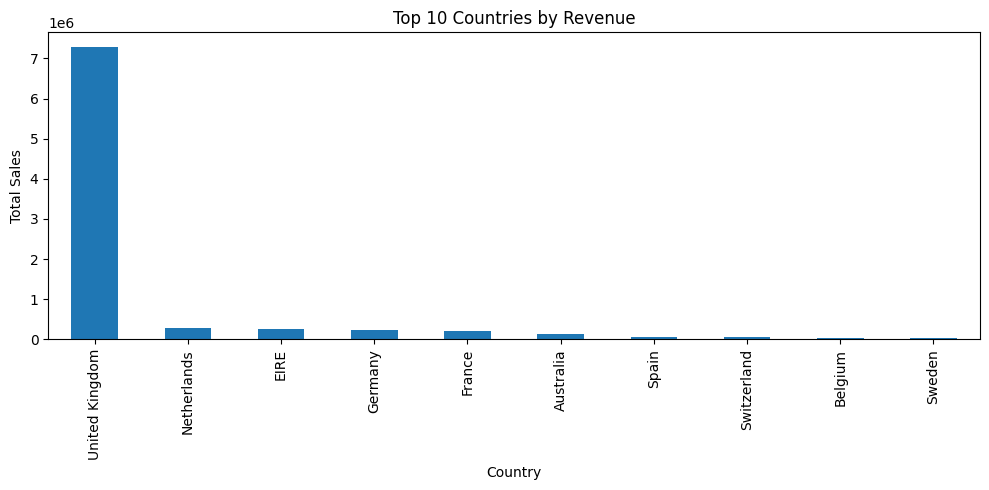

In [26]:
plt.figure(figsize=(10,5))
country_sales.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig(images_dir / 'sales_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

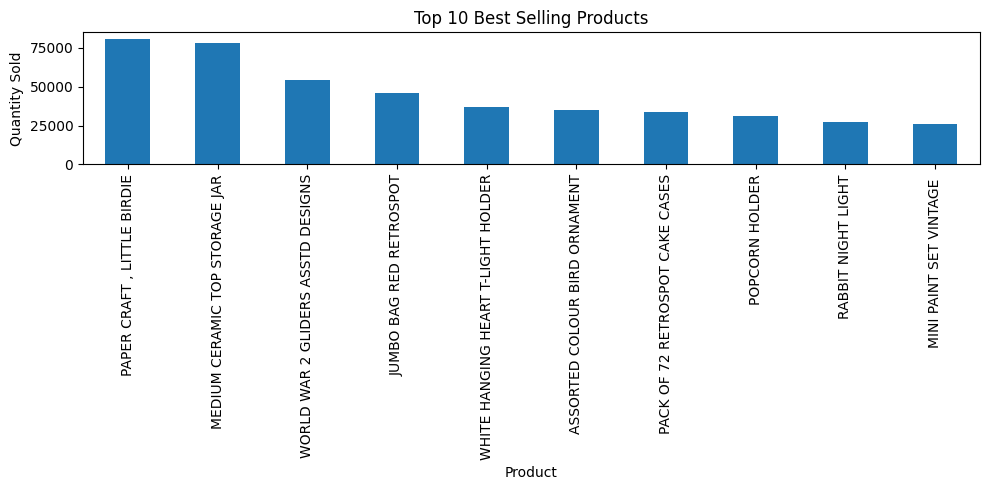

In [28]:
plt.figure(figsize=(10,5))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.savefig(images_dir / 'top_products.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [30]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

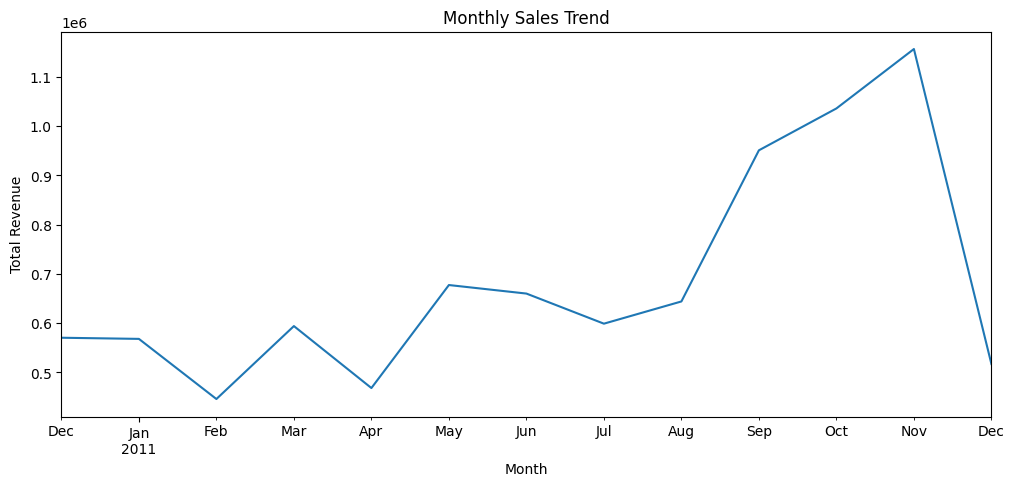

In [31]:
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

In [32]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

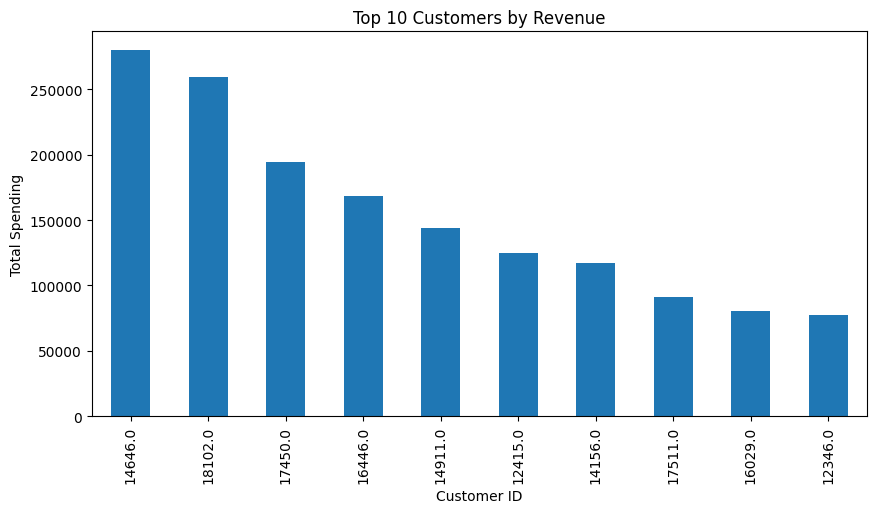

In [33]:
plt.figure(figsize=(10,5))
top_customers.head(10).plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

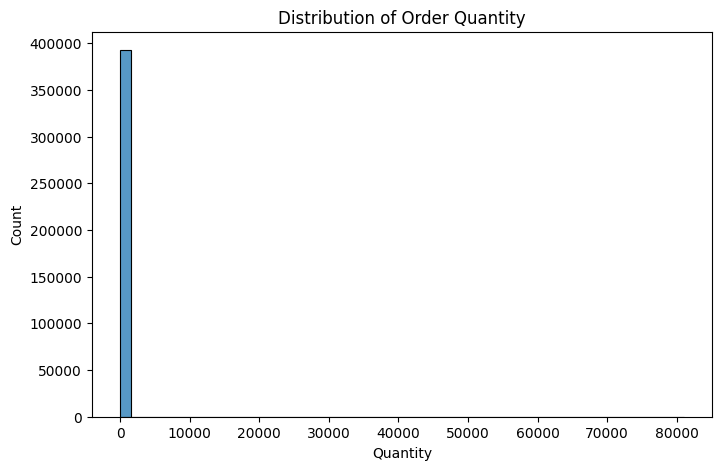

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=50)
plt.title("Distribution of Order Quantity")
plt.show()

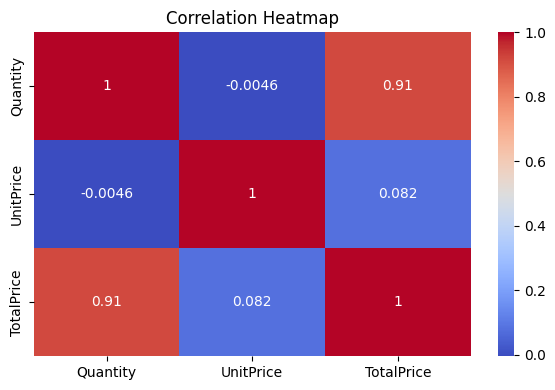

In [35]:
corr = df[['Quantity','UnitPrice','TotalPrice']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(images_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### Insight
The correlation heatmap shows the relationship between key numerical variables.

• Quantity and TotalPrice show a positive correlation, meaning larger purchase quantities lead to higher revenue.

• UnitPrice and Quantity have a weak correlation, suggesting that product price does not strongly influence how many items are purchased.

• TotalPrice is naturally influenced by both Quantity and UnitPrice since it is derived from their multiplication.

This analysis helps understand the key drivers of revenue in the online retail dataset.




## 7. Customer Behavior Analysis

In [36]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

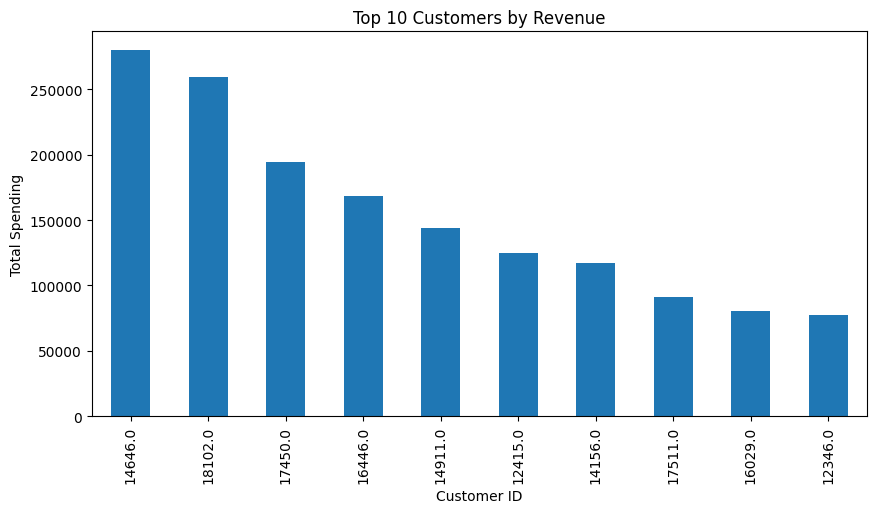

In [37]:
plt.figure(figsize=(10,5))
top_customers.head(10).plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")

plt.show()

In [38]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)

customer_orders.head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

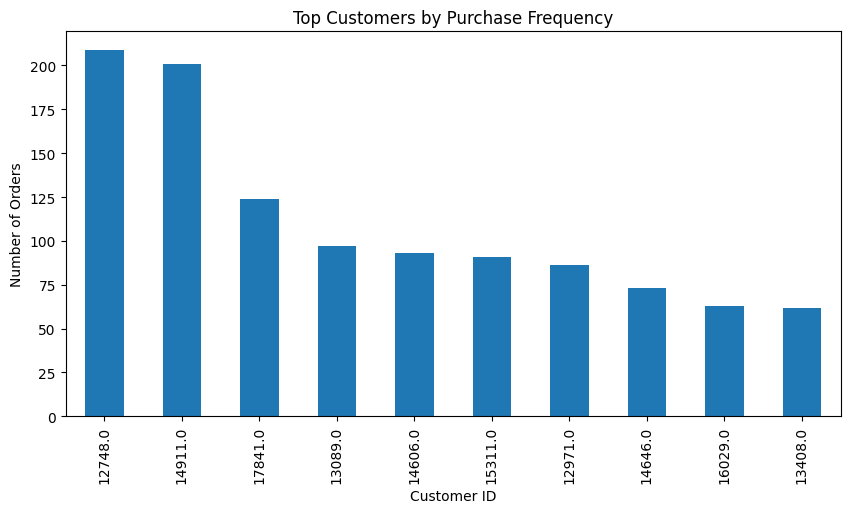

In [39]:
plt.figure(figsize=(10,5))
customer_orders.head(10).plot(kind='bar')

plt.title("Top Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.show()

In [40]:
customer_country = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

customer_country.head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

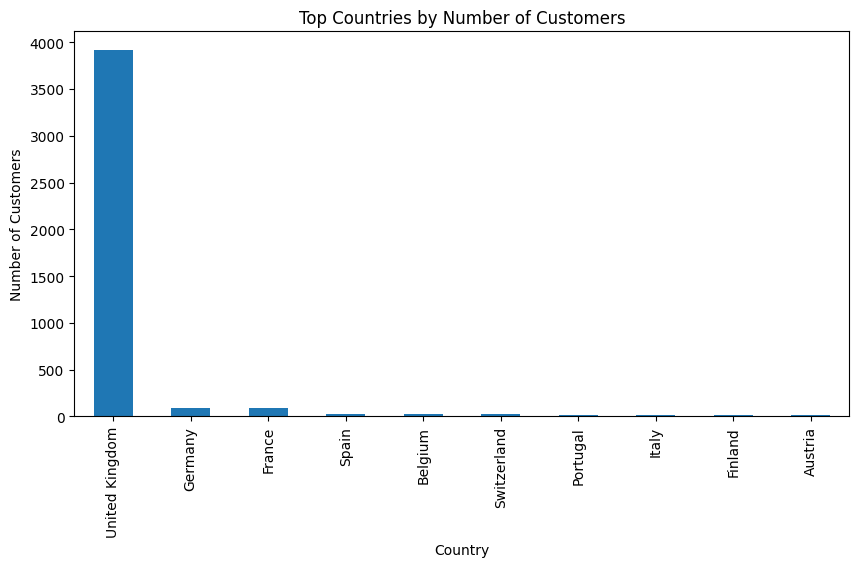

In [41]:
plt.figure(figsize=(10,5))
customer_country.head(10).plot(kind='bar')

plt.title("Top Countries by Number of Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

## 8. RFM Customer Segmentation

RFM Analysis is a customer segmentation technique used in marketing and business analytics.

RFM stands for:
• Recency – How recently a customer made a purchase
• Frequency – How often a customer makes purchases
• Monetary – How much money a customer spends

This analysis helps identify valuable customers and design targeted marketing strategies.

In [42]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [43]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [44]:
rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [45]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


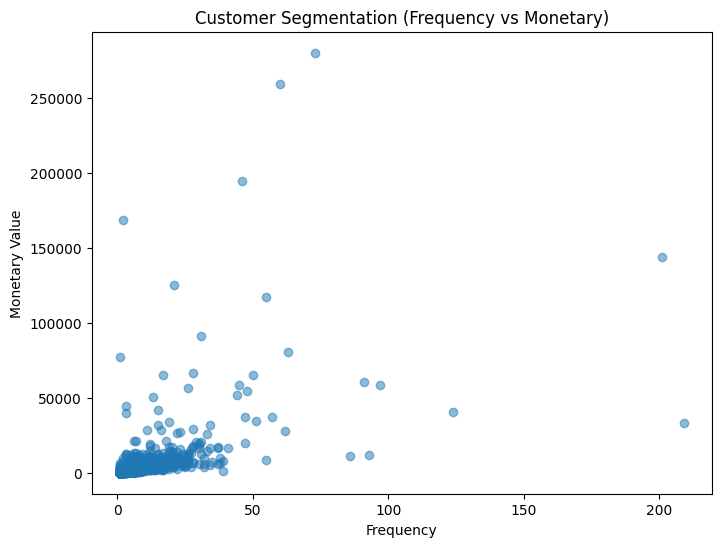

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.5)

plt.title("Customer Segmentation (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")

plt.show()

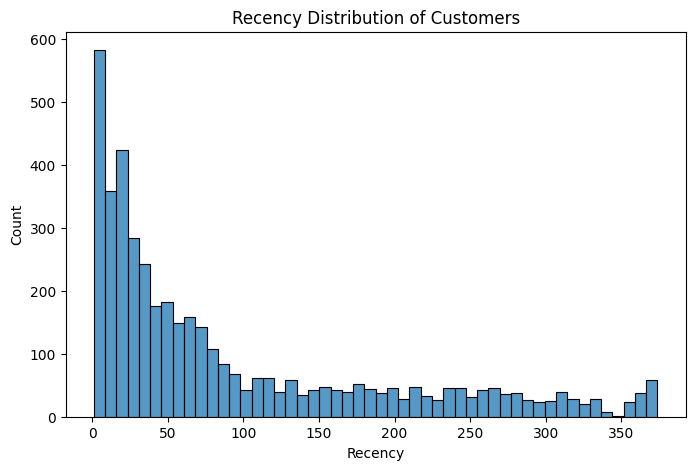

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=50)

plt.title("Recency Distribution of Customers")

plt.show()

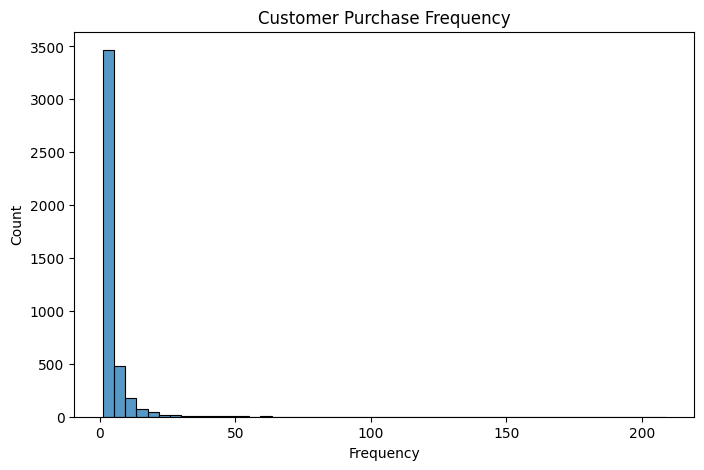

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=50)

plt.title("Customer Purchase Frequency")

plt.show()

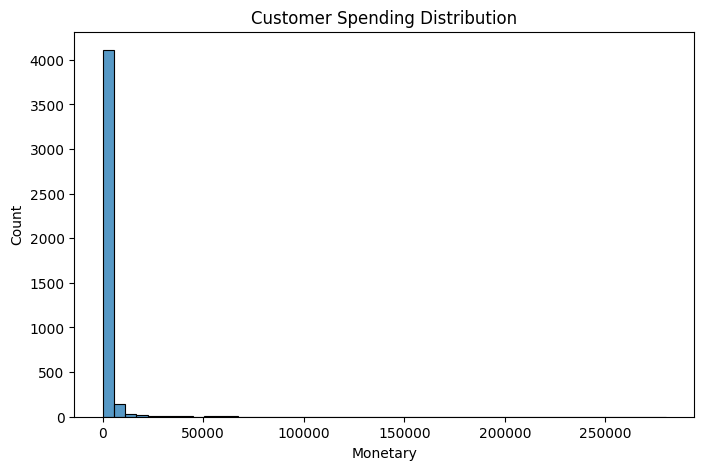

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=50)

plt.title("Customer Spending Distribution")

plt.show()

Key Insights from RFM Analysis

• A small percentage of customers contribute to the majority of revenue.
• High-frequency customers tend to generate higher monetary value.
• Many customers purchase only once or twice.
• Identifying high-value customers can help businesses implement loyalty programs.

## 9. Customer Segmentation using K-Means Clustering

K-Means clustering is an unsupervised machine learning algorithm used to group similar customers together.

Using RFM metrics (Recency, Frequency, Monetary), we can segment customers into groups such as:

• High-value customers
• Regular customers
• Low-value customers

This helps businesses design targeted marketing strategies.

In [50]:
import sklearn
print("Scikit-learn installed successfully")

Scikit-learn installed successfully


In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [52]:
rfm_data = rfm[['Recency','Frequency','Monetary']]

In [53]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_data)

In [54]:
kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


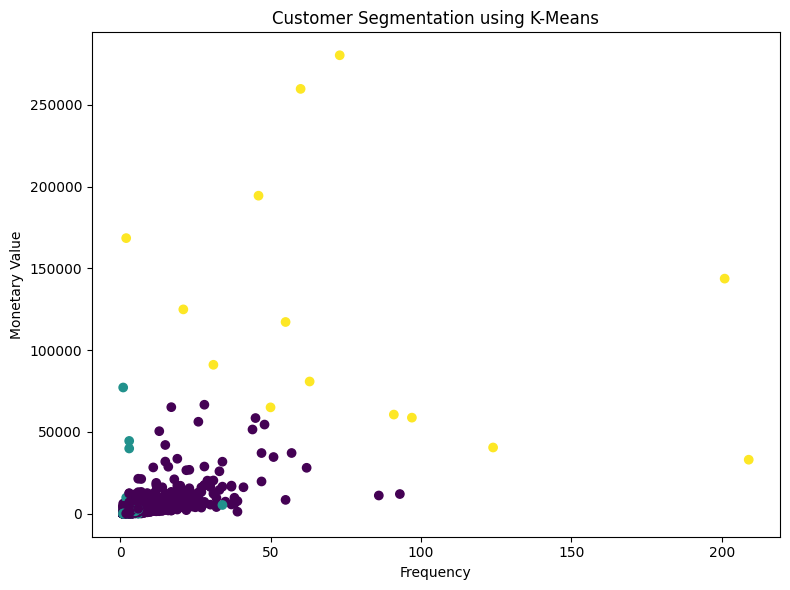

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(rfm['Frequency'], rfm['Monetary'], 
            c=rfm['Cluster'], cmap='viridis')

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.savefig(images_dir / 'customer_segmentation_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
rfm['Cluster'].value_counts()

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

In [57]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,40.983906,4.852677,2005.830431
1,246.023788,1.582800,629.357439
2,7.142857,80.214286,122748.792143


Customer Cluster Insights

Cluster 0 – High-value customers
These customers purchase frequently and spend large amounts. They are the most valuable customers.

Cluster 1 – Regular customers
These customers purchase occasionally with moderate spending.

Cluster 2 – Low-value customers
These customers rarely purchase and contribute less revenue.

## 10. Predictive Analysis (High-Value Customer Prediction)

In this section, we build a predictive model to identify high-value customers based on their purchasing behavior.

Step 1: Create Target Variable

In [58]:
rfm['HighValue'] = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

Step 2: Train Model

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


X = rfm[['Recency', 'Frequency']]
y = rfm['HighValue']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8375576036866359
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       431
           1       0.87      0.80      0.83       437

    accuracy                           0.84       868
   macro avg       0.84      0.84      0.84       868
weighted avg       0.84      0.84      0.84       868





A Logistic Regression model was built to predict high-value customers using Recency and Frequency features.

The model achieved an accuracy of approximately 84%, demonstrating good predictive capability.

## 11. 3D Visualization of Customer Segments

To better understand customer groups, we visualize the RFM clusters in a 3D space.

The three axes represent:
• Recency
• Frequency
• Monetary value

Each color represents a different customer segment identified by the K-Means clustering algorithm.

In [60]:
from mpl_toolkits.mplot3d import Axes3D

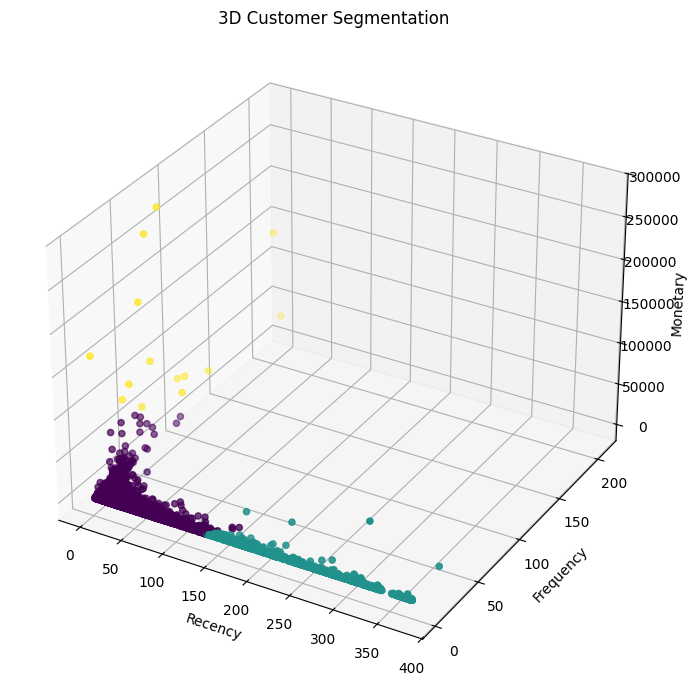

In [61]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segmentation")

plt.tight_layout()
plt.savefig(images_dir / 'customer_3d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight

The 3D visualization clearly shows distinct customer segments based on their purchasing behavior.

• One cluster represents high-value customers who purchase frequently and spend more.
• Another cluster represents moderate customers with occasional purchases.
• The final cluster represents low-engagement customers with infrequent purchases.

This segmentation helps businesses design personalized marketing strategies.

## 12. Business Insights



- A small group of customers contributes to the majority of total revenue, indicating high revenue concentration.
- Customers from the United Kingdom generate the highest number of transactions and revenue.
- Certain products dominate sales, showing clear customer preference patterns.
- High-frequency customers tend to generate more revenue and are key to business growth.
- There are customers with low recency (inactive), indicating potential churn risk.

## 13. Business Recommendations



- Focus marketing efforts on high-value customers to maximize revenue.
- Provide loyalty rewards and exclusive offers to frequent buyers.
- Target inactive or at-risk customers with personalized campaigns to improve retention.
- Increase inventory and promotion for top-selling products.
- Expand marketing strategies in high-performing regions like the United Kingdom.

## 14. Conclusion

This project analyzed online retail transaction data to understand customer purchasing behavior.

Using exploratory data analysis and machine learning techniques such as RFM segmentation and K-Means clustering, we identified valuable customer segments and key revenue drivers.

The insights generated from this analysis can help businesses improve marketing strategies, increase customer retention, and maximize revenue.

This project demonstrates how data-driven decision making can help businesses optimize customer engagement and revenue.